# Stats and visuals for the public spine

This is a pdf generated from a notebook, using the most recent version of the public spine. If anything is useful the graphs can be saved as pngs and accessed directly.

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot
import upsetplot


In [2]:
basefilename = '/Users/fionack/Projects/TSO_project/public_spine_data/TSCS_spine'
#basefilename = '/Users/fionack/Projects/public_spine'
#basefilename = '/Users/fionack/Projects/TSO_project/tso-database-builder/main_spine.ccew.oscr.ccni.ch.csv'#main_spine.ccew.oscr'
spine_df = pd.read_csv(basefilename+'.spine.csv',usecols=['uid','normalisedname','registerdate'])
extras_df = pd.read_csv(basefilename+'.supplementary.csv',usecols=['uid','normalisedname','source_register'])
matches_df = pd.read_csv(basefilename+'.matches.csv',low_memory=False)

print(f'There are {spine_df.shape[0]} rows in the main spine, {extras_df.shape[0]} rows of supplementary data and {matches_df.shape[0]} matches found.\n')

#source_order = ['CCEW','OSCR','CCNI','CH','COOP','MPR' 'SHR','SHPE', 'CIS','CQC'  ]
source_order = {'CHC': 1, 
                'SC' : 2,
                'NIC': 3, 
                'COH' : 4,
                'COOP' : 5,
                'MPR' : 6,
                'SHR' : 7,
                'SHPE' : 8,
                'CIS' : 9,
                'CQC' : 10 }


There are 772391 rows in the main spine, 943638 rows of supplementary data and 126153 matches found.



July 2025: There are 761923 rows in the main spine, 876626 rows of supplementary data and 108609 matches found.
Sept 2025 (data from Feb 2025): There are 753569 rows in the main spine, 895186 rows of supplementary data and 117007 matches found.
Nov 2025: There are 772256 rows in the main spine, 942571 rows of supplementary data and 126247 matches found.

In [46]:
772256-761923

10333

## Counts per source in main spine

In [4]:

july_to_nov = {
'CHC'     :[346390,  349432,],
'COH'     :[325403,  331756,],
'SC'       :[52506,   53245,],
'MPR'      :[19903,   19816,],
'COOP'      :[9481,    9757,],
'NIC'       :[8108,    8243,],
'SHR'        :[109,     111,],
'SHPE'        :[23,      31,],
}

july_to_nov_df = pd.DataFrame(july_to_nov).T
july_to_nov_df.reset_index(inplace=True)
july_to_nov_df.columns=['source','july2025','nov2025']
july_to_nov_df['nov-jul'] = july_to_nov_df['nov2025'] - july_to_nov_df['july2025']


In [5]:

july_to_nov_df

,source,july2025,nov2025,nov-jul
0,CHC,346390,349432,3042
1,COH,325403,331756,6353
2,SC,52506,53245,739
3,MPR,19903,19816,-87
4,COOP,9481,9757,276
5,NIC,8108,8243,135
6,SHR,109,111,2
7,SHPE,23,31,8


In [62]:
spine_df['registerdate'] = pd.to_datetime(spine_df['registerdate'], errors='coerce', dayfirst=True)
spine_df[spine_df['basesource']=='SC']['registerdate'].max()

Timestamp('2025-10-31 00:00:00')

basesource
CHC     349432
COH     331756
SC       53245
MPR      19816
COOP      9757
NIC       8243
SHR        111
SHPE        31
Name: count, dtype: int64
source_codes = {'SHR', 'NIC', 'SHPE', 'COOP', 'SC', 'COH', 'MPR', 'CHC'}
/Users/fionack/Projects/TSO_project/public_spine_data/TSCS_spine.sources.png


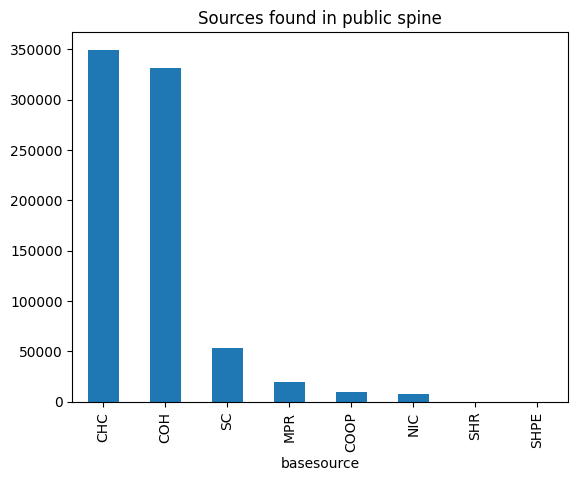

In [3]:
spine_df['basesource'] = spine_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = spine_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
print(source_counts)
print(f"source_codes = {set(spine_df['basesource'])}")
source_counts.plot(kind='bar')
pyplot.title('Sources found in public spine')
print('%s.sources.png'%basefilename)
pyplot.savefig('%s.sources.png'%basefilename)


basesource
CHC     240950
COH     103320
SC       20924
MPR      12076
COOP      9374
NIC       4159
CIS       2170
SHPE      1311
CQC        961
SHR         13
Name: count, dtype: int64


Text(0.5, 1.0, 'Sources found in supplementary data')

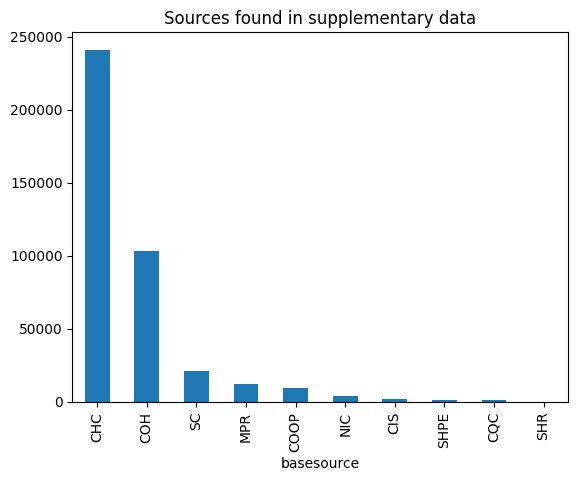

In [21]:
extras_df['basesource'] = extras_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

extras_sources = extras_df[['uid','basesource']].drop_duplicates()
extras_source_counts = extras_sources['basesource'].value_counts(dropna=False)
print(extras_source_counts)
extras_source_counts = extras_source_counts.rename(index={np.nan: 'NaN'})
extras_source_counts.plot(kind='bar')
pyplot.title('Sources found in supplementary data')


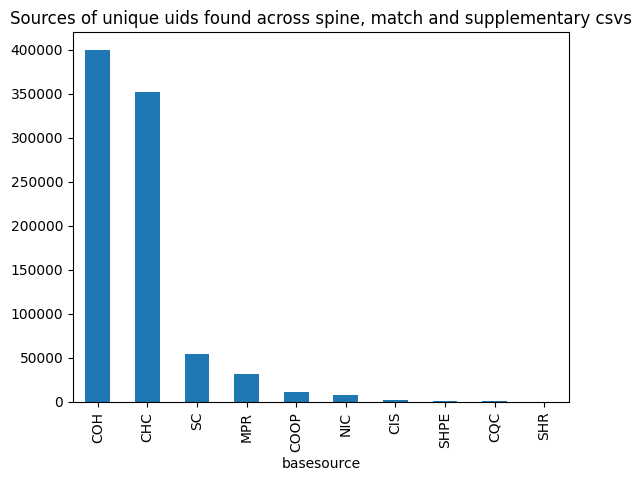

In [22]:
# find all uids used across all data:
uid_set = set(list(spine_df['uid']) + list(matches_df['orgA_uid']) + list(matches_df['orgB_uid']) + list(extras_df['uid']))

all_df = pd.DataFrame(uid_set,columns=['uid'])
#print(all_df)
all_df['basesource'] = all_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = all_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
#print(source_counts)
source_counts.plot(kind='bar')

pyplot.title('Sources of unique uids found across spine, match and supplementary csvs')

pyplot.savefig('%s.all.sources.png'%basefilename)

source_counts = [f"{source} & {count} \\\\ \\hline\n" for source, count in source_counts.items()]

with open(basefilename+'.all_used_orgs.tab.tex', 'w') as ofile:

    ofile.write('\\begin{table}[h]\n  \\centering\n')
    ofile.write('\\begin{tabular}{|l|r|}\n    \\hline\n')
    ofile.write('Source & Count of orgs \\\\ \\hline \\hline\n')

    for i in source_counts:
        ofile.write(i)

    ofile.write('\\end{tabular}\n')
    ofile.write('\\caption{Count of organisations per source}\n')
    ofile.write('\\label{tab:all_used_orgs}\n')
    ofile.write('\\end{table}\n')





In [23]:
spine_uids = set(spine_df['uid'])
print(f'There are {len(spine_uids)} unique uids in the spine data')
matches_uids = set(matches_df['orgA_uid']) | set(matches_df['orgB_uid'])
matches_not_spine = matches_uids - spine_uids
print(f'There are {len(matches_not_spine)} unique uids in the matches data that are not in the spine data')

with open(basefilename + '.all_orgs.spine_match.tab.tex', 'w') as ofile:
    ofile.write('\\begin{tabular}{|l|r|r|r|}\n    \\hline\n')
    ofile.write(' & Count of orgs  & Count of orgs  & Total count\\\\ \n')
    ofile.write(' Source &  in spine & matched to spine & per source\\\\ \\hline \\hline\n')

    for i in source_order:
        
        count_in_spine = len([uid for uid in list(spine_uids) if f'GB-{i}' in uid])
        count_in_matches = len([uid for uid in list(matches_not_spine) if f'GB-{i}' in uid])
        print(f'Processing {i}: {count_in_spine} in spine, {count_in_matches} in matches')
        total = count_in_spine + count_in_matches
        ofile.write(f'{i} & {count_in_spine} & {count_in_matches} & {total}\\\\ \\hline\n')

    ofile.write('\\end{tabular}\n')

print('Table written to %s'%basefilename + '.all_orgs.spine_match.tab.tex')

There are 753569 unique uids in the spine data
There are 107297 unique uids in the matches data that are not in the spine data
Processing CHC: 346390 in spine, 5323 in matches
Processing SC: 52487 in spine, 1421 in matches
Processing NIC: 8108 in spine, 0 in matches
Processing COH: 317051 in spine, 82716 in matches
Processing COOP: 9497 in spine, 1328 in matches
Processing MPR: 19904 in spine, 12017 in matches
Processing SHR: 109 in spine, 50 in matches
Processing SHPE: 23 in spine, 1311 in matches
Processing CIS: 0 in spine, 2170 in matches
Processing CQC: 0 in spine, 961 in matches
Table written to /Users/fionack/Projects/TSO_project/public_spine_data/TSCS_spine.all_orgs.spine_match.tab.tex


In [24]:
82716-74364+317051

325403

                 match_type  count
0                       ftc  61556
1  companyid - id_in_source  36310
2   companyid - coop mutual  10180
3                      oscr   4295
4               name - care   3564
5            name - housing    693
6     companyid - companyid    371
7        name - crossborder     38


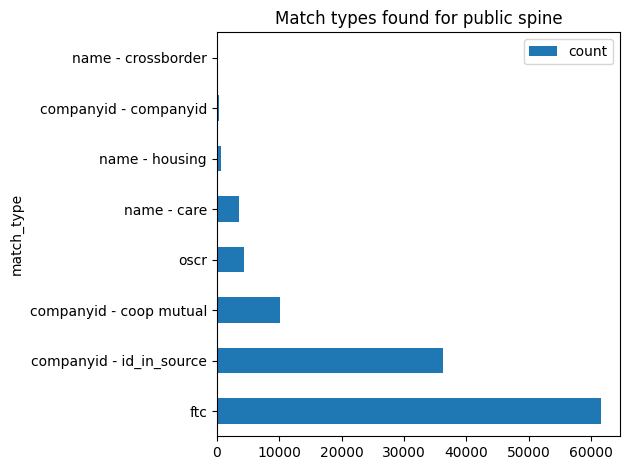

In [25]:

match_types = matches_df['match_type'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})
match_types = match_types.reset_index()
match_types.columns = ['match_type','count']

print(match_types)
match_types.plot(y='count', x='match_type', kind='barh')
pyplot.title('Match types found for public spine')
pyplot.tight_layout()
pyplot.savefig('%s.matchtypes.png'%basefilename)
pyplot.show()
# also think of how to plot this so that identical matches are shown in a different way - pairs of organisations which are matched by ftc and also name, for example - this chart doesn't differentiate



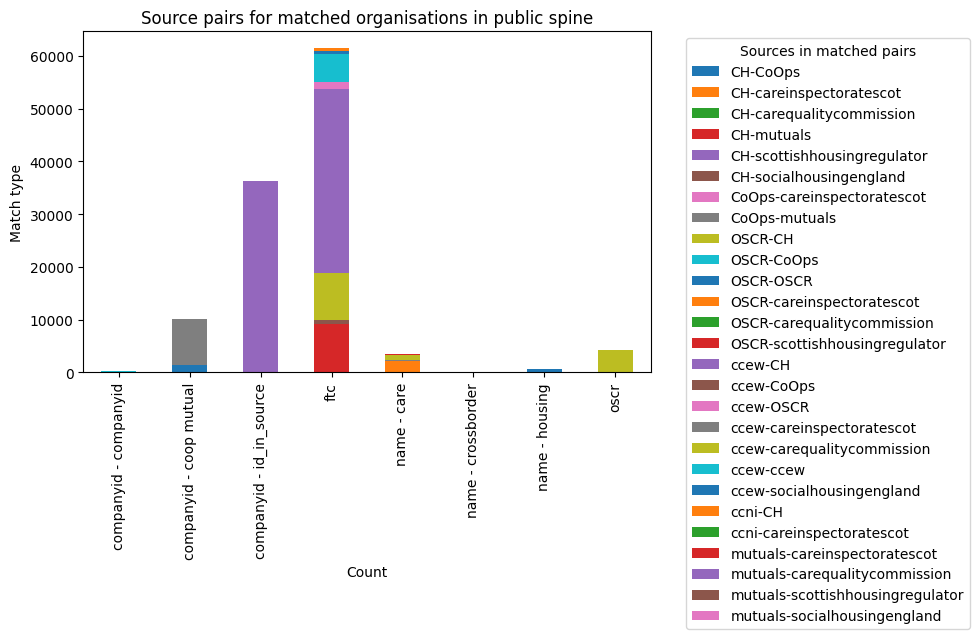

<Figure size 640x480 with 0 Axes>

In [26]:
matches_df['source-source'] = matches_df.apply(lambda row: '%s-%s'%(row['orgA_source'],row['orgB_source']), axis=1)
match_types = matches_df.groupby('match_type')['source-source'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})

# Convert Series to DataFrame for plotting
match_types = match_types.unstack().fillna(0)

# Plot the data
match_types.plot(kind='bar', stacked=True, figsize=(10, 6))
pyplot.title('Source pairs for matched organisations in public spine')
pyplot.legend(title='Sources in matched pairs', bbox_to_anchor=(1.05, 1), loc='upper left')
pyplot.xlabel('Count')
pyplot.ylabel('Match type')
pyplot.tight_layout()
pyplot.show()
pyplot.savefig('%s.match_source_pairs.types.png'%basefilename)

In [27]:
uids_in_matches_df = set(matches_df['orgA_uid'] + matches_df['orgB_uid'])
print(f'Unique uids in matches csv = {len(uids_in_matches_df)}')
print(f"Unique uids in main spine csv = {len(set(spine_df['uid']))}")

orga_uids = set(matches_df['orgA_uid'])
orgb_uids = set(matches_df['orgB_uid'])

print(f'Number of unique organisations in position OrgA = {len(orga_uids)}, and unique OrgB uids = {len(orgb_uids)}')

Unique uids in matches csv = 114447
Unique uids in main spine csv = 753569
Number of unique organisations in position OrgA = 103801, and unique OrgB uids = 107645


In [28]:
# code to generate the table used in release_info.tex
# with columns source  &  count in   &  count in     &  count in \\
#                      &  spine.csv  &  matches.csv  &  matches.csv \\


# Initialize an empty list to store the results
table_data = []

spine_df['basesource'] = spine_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

matches_uids_df = pd.DataFrame(set(list(matches_df['orgA_uid'])+list(matches_df['orgB_uid'])),columns=['uid'])

matches_uids_df['basesource'] = matches_uids_df.apply(lambda row: row['uid'].split('-')[1], axis=1)


for source in source_order:
    # Get unique UIDs for the source in both dataframes
    spine_uids = spine_df.loc[spine_df['basesource'] == source, 'uid'].unique()
    matches_uids = matches_uids_df.loc[matches_uids_df['basesource'] == source, 'uid'].unique()

    # Calculate counts
    count_in_spine = len(spine_uids)
    count_in_matches = len(matches_uids)
    count_in_matches_not_spine = len(set(matches_uids) - set(spine_uids))

    # Append the data for the source
    table_data.append([source, count_in_spine, count_in_matches, count_in_matches_not_spine])


rows=[f'{i[0]} & {i[1]} & {i[2]} & {i[3]} \\\\' for i in table_data]

latex_table = (
    "\\begin{table}[h]\n"
    "\\centering\n"
    "\\begin{tabularx}{0.6\\textwidth}{|X|r|r|r|}\n"
    "\\hline\n"
    "source & count in & count in & count in \\\\\n"
    "& spine.csv &  matches.csv &  matches.csv \\\\\n"
    "&&& not spine.csv \\\\\n"
    +'\n'.join(rows)
    +"\\hline\n"
    "\\end{tabularx}\n"
    "\\caption{Counts of unique uids in spine and matches csvs}\n"
    "\\end{table}\n"
)

# Print the LaTeX table


print(latex_table)





\begin{table}[h]
\centering
\begin{tabularx}{0.6\textwidth}{|X|r|r|r|}
\hline
source & count in & count in & count in \\
& spine.csv &  matches.csv &  matches.csv \\
&&& not spine.csv \\
CHC & 346390 & 77656 & 5323 \\
SC & 52487 & 12921 & 1421 \\
NIC & 8108 & 656 & 0 \\
COH & 317051 & 93442 & 82716 \\
COOP & 9497 & 10223 & 1328 \\
MPR & 19904 & 12056 & 12017 \\
SHR & 109 & 50 & 50 \\
SHPE & 23 & 1311 & 1311 \\
CIS & 0 & 2170 & 2170 \\
CQC & 0 & 961 & 961 \\\hline
\end{tabularx}
\caption{Counts of unique uids in spine and matches csvs}
\end{table}



Find the numbers of matches found by any combination of match types:

In [29]:
match_types_dict = {}  #
uid_uid_match_dict = {}
#print(matches_df)                   
matches_df['uid-uid'] = matches_df.apply(lambda row: '%s:%s' % tuple(sorted([row['orgA_uid'], row['orgB_uid']])), axis=1)
#print(matches_df)
#
unique_uidA_uidB = set(matches_df['uid-uid'])
#print(unique_uidA_uidB)
print(f'Number of uniquely matched pairs of orgs in matches csv = {len(unique_uidA_uidB)} (of {matches_df.shape[0]} rows in matches csv)')
print(f' ==> number of org pairs found in multiple ways = {matches_df.shape[0]-len(unique_uidA_uidB)}')
#matches_df['uid-uid'].value_counts()



Number of uniquely matched pairs of orgs in matches csv = 114447 (of 117007 rows in matches csv)
 ==> number of org pairs found in multiple ways = 2560


In [30]:
import pandas as pd
import os
from matplotlib import pyplot as plt
import upsetplot
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


source_order = {'CHC': 1, 
                'SC' : 2,
                'NIC': 3, 
                'COH' : 4,
                'COOP' : 5,
                'MPR' : 6,
                'SHR' : 7,
                'SHPE' : 8,
                'CIS' : 9,
                'CQC' : 10 }

def plot_upset_matches_multi(basefilename,include = 'all'):#_unmatched_orgs=True,only_unmatched_orgs=False):
    if not include in ['all','only_matched','only_unmatched']:
        raise ValueError("Invalid argument for include, must be in ['all','only_matched','only_unmatched']")

    # Read input files
    #all_uids = pd.read_csv(basefilename + '.spine.csv', usecols=['uid'])
    #matches_df = pd.read_csv(basefilename + '.matches.csv')

    all_uids = pd.read_csv(basefilename + '.spine.csv', usecols=['uid'], dtype={'uid': str})
    matches_df = pd.read_csv(basefilename + '.matches.csv', usecols=['orgA_uid','orgB_uid'],dtype=str, low_memory=False)

    
    # Create a dictionary to map each uid to its matches
    match_dict = {}
    

    for index, row in matches_df.iterrows():
        orgA_uid, orgB_uid = row['orgA_uid'], row['orgB_uid']
        if orgA_uid not in match_dict:
            match_dict[orgA_uid] = set()
        if orgB_uid not in match_dict:
            match_dict[orgB_uid] = set()
        match_dict[orgA_uid].add(orgB_uid)
        match_dict[orgB_uid].add(orgA_uid)
    
    def find_matches(uid):
        # Use an iterative approach to find all matches
        found = set()
        stack = [uid]
        while stack:
            current = stack.pop()
            if current not in found:
                found.add(current)
                stack.extend(match_dict.get(current, []))
        return found
    
    # Process each uid and find all matched uids
    m_list = []
    for uid in all_uids['uid']:
        matched = find_matches(uid)
        matched.add(uid)
        try:
            sources = [i.split('-')[1] for i in matched]
            m_list.append(sources)
        except Exception as e:
            print(f'{e}: uid = {uid}, matched = {matched}')
    
    # Create a DataFrame for the upset plot
    series = pd.Series(m_list)
    source_list = list(source_order.keys())
    df = pd.DataFrame({item: series.apply(lambda x: item in x) for item in source_list})
    
    # Group by source_list and get the size
    df_grouped = df.groupby(source_list).size()
    
    if include == 'only_matched':
    # Filter out rows with only one 'true' value
        df_grouped = df_grouped[df_grouped.index.map(sum) > 1]

    if include == 'only_unmatched':
        df_grouped = df_grouped[df_grouped.index.map(sum) ==1]
    
    
    # Plot using upsetplot
    upsetplot.plot(df_grouped, orientation='horizontal')
    if include == 'all':
        plt.title("Data sources used for each organisation found in %s" % os.path.basename(basefilename).replace('_',' ').capitalize())
        plt.savefig('%s.all_orgs.upsetplot.png' % basefilename)
    elif include == 'only_matched':
        plt.title("Data sources for matched organisations only, found in %s" % os.path.basename(basefilename).replace('_',' ').capitalize())
        plt.savefig('%s.matched_orgs.upsetplot.png' % basefilename)
    elif include == 'only_unmatched':
        plt.title("Data sources for organisations found in one source only")
        plt.savefig('%s.unmatched.upsetplot.png' % basefilename)
    
    plt.show()
    return df_grouped




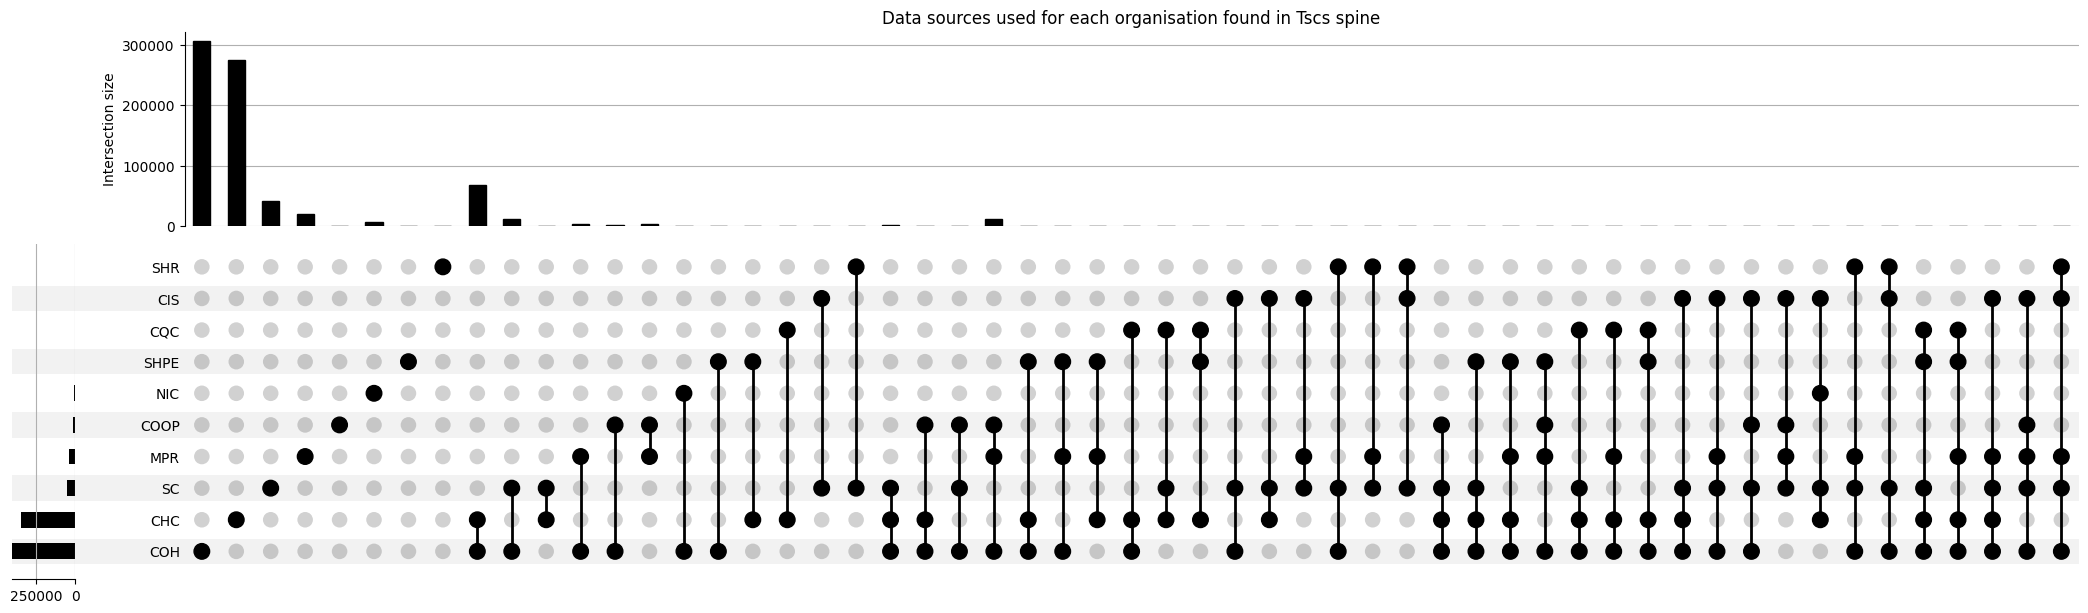

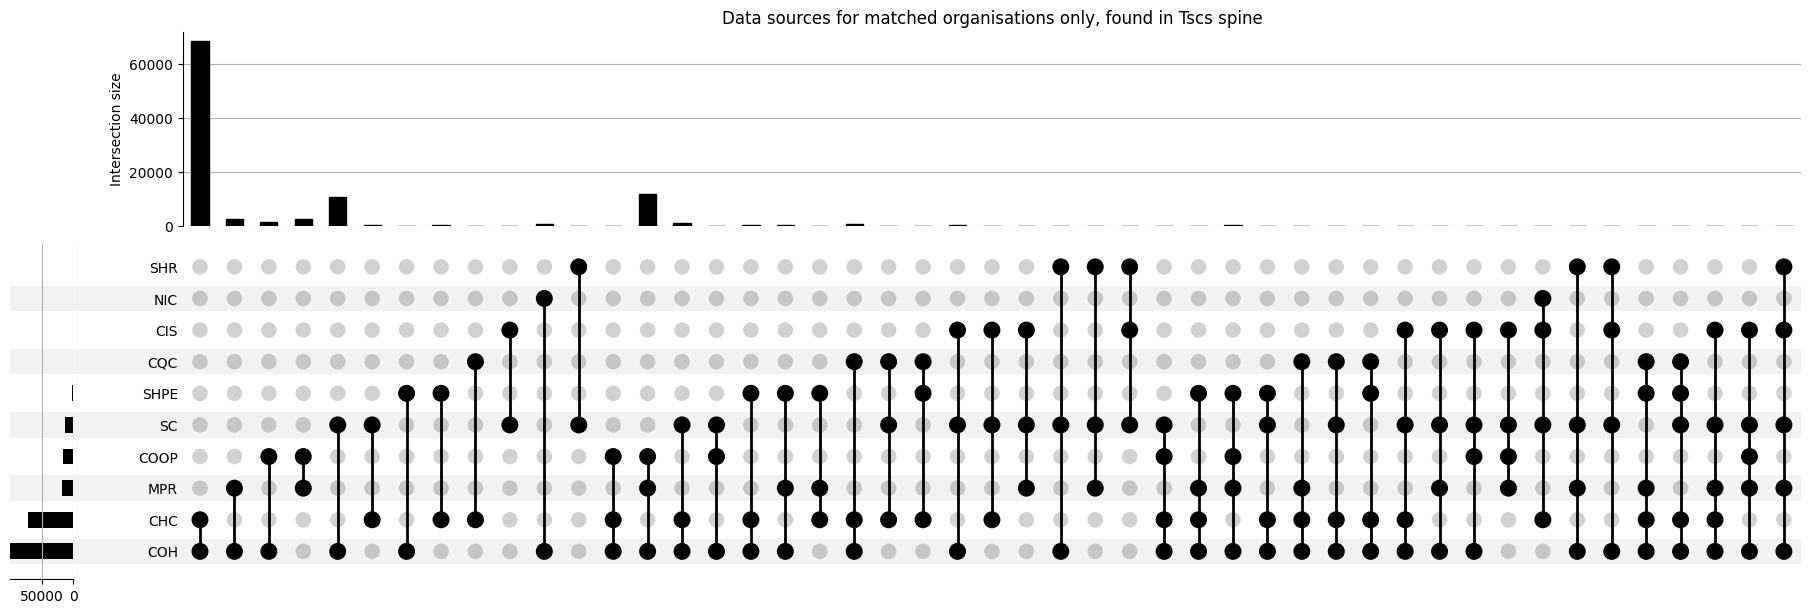

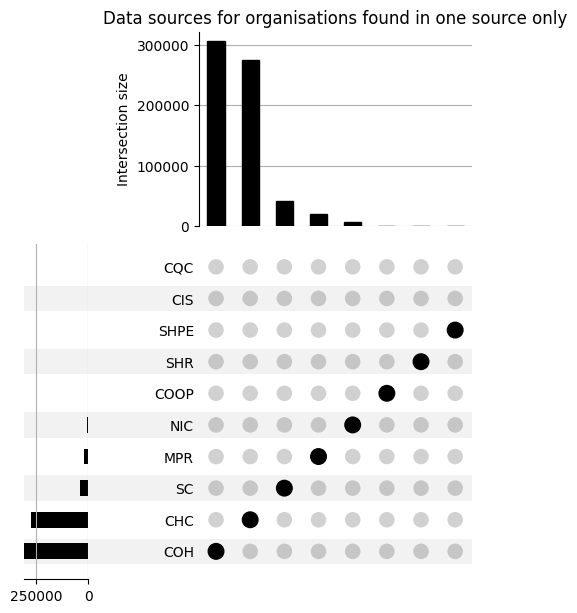

In [31]:
a=plot_upset_matches_multi(basefilename,'all')
b=plot_upset_matches_multi(basefilename,'only_matched')
c=plot_upset_matches_multi(basefilename,'only_unmatched')

Plotting the organisations matched in more than one way through our algorithm:

Text(0, 0.5, 'Count of org pairs matched')

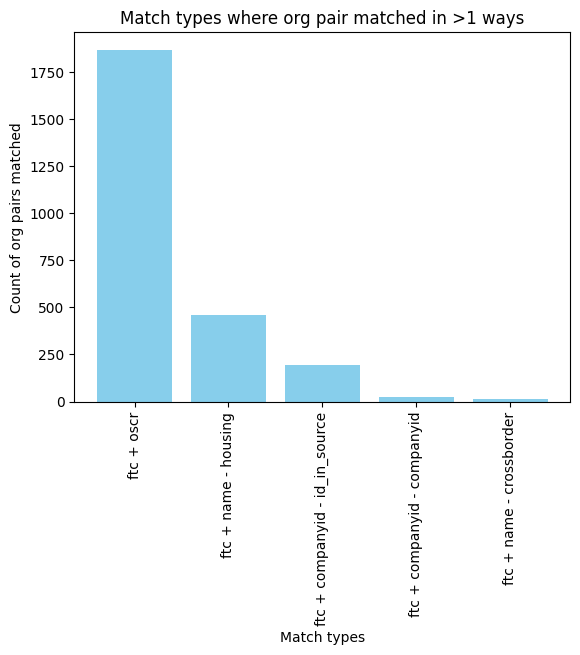

In [32]:

# plot the orgs matched in multiple ways:

def concat_strings(series):
    return ' + '.join(series)


concatenated = matches_df.groupby('uid-uid')['match_type'].apply(concat_strings).reset_index()
concatenated.columns = ['uid-uid','match_type']


counts = matches_df['uid-uid'].value_counts().reset_index()
counts.columns = ['uid-uid', 'count']


result = pd.merge(concatenated, counts, on='uid-uid')

two_matches= result[result['count']>1]
match_type_counts = two_matches['match_type'].value_counts().reset_index()
match_type_counts.columns = ['match_type', 'count']
pyplot.bar(match_type_counts['match_type'], match_type_counts['count'], color='skyblue')
pyplot.xticks(rotation=90)
pyplot.title('Match types where org pair matched in >1 ways')
pyplot.xlabel('Match types')
pyplot.ylabel('Count of org pairs matched')

#pyplot.bar(two_matches['match_type'],height=two_matches.groupby['match_type'].value_counts())



Counts of companies house legal forms. Need to map spine back onto CH data to include the companytype information (this is lost in pre-processing as we only care about overall source at that stage).

In [33]:
raw_ch_df = pd.read_csv('../../raw_data/CH.all.csv',usecols=['uid','companytype'])
print(raw_ch_df.shape)
raw_ch_df.drop_duplicates(inplace=True)
print(raw_ch_df.shape)

(3867490, 2)
(586527, 2)


In [34]:

def cic_mapping(s):
    if 'community-interest-company' in s:
        return 'Community Interest Company'
    if 'private-limited-guarant' in s or 'CLG' in s or 'PRI/LTD BY GUAR/NSC' in s or 'PRI/LBG/NSC' in s: 
        return 'Company Limited by Guarantee'
    else: return s

raw_ch_df['compressed_source'] = raw_ch_df['companytype'].apply(cic_mapping)

In [35]:
source_df = raw_ch_df['companytype'].value_counts()
source_df_sorted_by_source = source_df.sort_index()

source_df.sort_index()
source_df_sorted_by_source.sort_values(ascending=False, inplace=True)
print(source_df_sorted_by_source)
# output the source_df_sorted_by_source to a latex table
source_df_sorted_by_source.to_latex('../CH.companytype.tab.tex')
with open('../CH.companytype.tab.tex', 'w') as ofile:

    ofile.write('\\begin{tabular}{|l|r|}\n    \\hline\n')
    ofile.write('Company type & Count \\\\ \\hline \\hline\n')

    for i in source_df_sorted_by_source.items():
        ofile.write(f'{i[0]} & {i[1]} \\\\ \\hline\n')

    ofile.write('\\end{tabular}\n')



companytype
private-limited-guarant-nsc                                                                  193501
PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)                        133809
private-limited-guarant-nsc-limited-exemption                                                 67796
Community Interest Company                                                                    42504
PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)     41766
private-limited-guarant-nsc community-interest-company                                        41173
Charitable Incorporated Organisation                                                          38318
Registered Society                                                                            10957
ltd community-interest-company                                                                 9343
Scottish Charitable Incorporated Organisation                                           

compressed_source
Charitable Incorporated Organisation              38318
Community Interest Company                        93216
Company Limited by Guarantee                     436872
Industrial and Provident Society                    162
Registered Society                                10957
Scottish Charitable Incorporated Organisation      7002
Name: count, dtype: int64


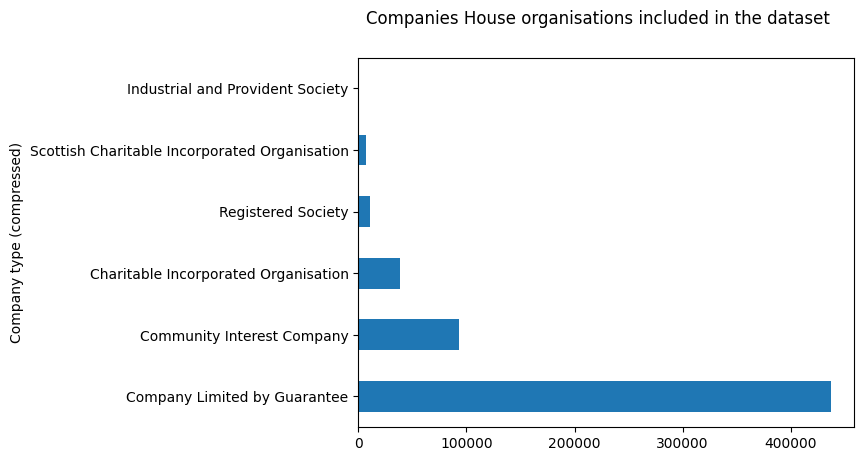

In [36]:
source_df = raw_ch_df['compressed_source'].value_counts()
source_df_sorted_by_source = source_df.sort_index()

source_df.sort_index()
print(source_df_sorted_by_source)
source_df_sorted_by_source.sort_values(ascending=False, inplace=True)
source_df.plot(kind='barh')
pyplot.suptitle('Companies House organisations included in the dataset')
pyplot.ylabel('Company type (compressed)')
pyplot.savefig('../CH_dist.png',bbox_inches='tight')

with open('../CH_dist.tab.tex', 'w') as ofile:

    ofile.write('\\begin{tabular}{|l|r|}\n    \\hline\n')
    ofile.write('Company type & Count \\\\ \\hline \\hline\n')

    for i in source_df_sorted_by_source.items():
        ofile.write(f'{i[0]} & {i[1]} \\\\ \\hline\n')

    ofile.write('\\end{tabular}\n')


In [37]:
# preprocessed CH data:
subspine_ch_df = pd.read_csv('../../public_spine_data/CH_all.spine.csv')
supp_ch_df = pd.read_csv('../../public_spine_data/CH_all.spine.supplementary.csv')


/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_80471/3635633977.py:2: DtypeWarning: Columns (8,14) have mixed types. Specify dtype option on import or set low_memory=False.
  subspine_ch_df = pd.read_csv('../../public_spine_data/CH_all.spine.csv')


In [38]:
len(subspine_ch_df['uid'].unique())

399767

In [39]:
len(supp_ch_df['uid'].unique())

62488

In [40]:
s={'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745, 'CH': 362311, 'CoOps': 9195, 'mutuals': 18649, 'ScottishHousingRegulator': 158, 'SocialHousingEngland': 9, 'CareInspectorateScot': 1582, 'CareQualityCommission': 35654}
m={'CCEW': 5191, 'CH': 74964, 'SocialHousingEngland': 1981, 'CareQualityCommission': 1376, 'OSCR': 1569, 'CCNI': 1, 'CareInspectorateScot': 2689, 'CoOps': 1368, 'mutuals': 20102}
t=920734

In [41]:
import re
def normalise_postcode(postcode):
    '''normalise postcode to upper case, remove spaces and hyphens'''
    postcode = postcode.replace('-',' ').strip()
    postcode = re.sub(r'\s+', ' ', postcode)
    postcode = postcode.upper()
    
    postcode_regex = re.compile(r"^(GIR 0AA|[A-Z]{1,2}[0-9][0-9A-Z]? ?[0-9][A-Z]{2})$", re.IGNORECASE)
    partial_pc_regex = re.compile(r"^([A-Z]{1,2}[0-9][0-9A-Z]? ?[0-9]?[A-Z]?)$", re.IGNORECASE)
    if not postcode_regex.match(postcode):
        if partial_pc_regex.match(postcode):
            postcode = postcode
        else:
            postcode = ''
    return postcode                    